# Datathon Passos Mágicos — Fase 5  
## Modelo Preditivo de Risco de Defasagem — Versão Melhorada

Este notebook responde à **Pergunta 9** com uma abordagem mais robusta para estimar o **risco de defasagem**.

### Melhorias aplicadas nesta versão
- **split temporal**: treino com anos anteriores e teste em 2024, reduzindo vazamento temporal;
- **baseline comparativo**: Logistic Regression vs. Random Forest;
- **validação cruzada** no conjunto de treino;
- **tuning de hiperparâmetros** com `GridSearchCV`;
- **engenharia de atributos** simples para enriquecer o sinal;
- **avaliação mais completa** com ROC AUC, F1, precision, recall e matriz de confusão;
- **importância das variáveis** por `permutation_importance`;
- export do **modelo final** e das **métricas** para uso no Streamlit.


In [40]:
from pathlib import Path
import sys

# Resolve a raiz do projeto mesmo rodando a partir de /notebooks
PROJECT_ROOT = Path.cwd().resolve().parent
APP_PATH = PROJECT_ROOT / "app"

for p in [PROJECT_ROOT, APP_PATH]:
    if str(p) not in sys.path:
        sys.path.append(str(p))

print("PROJECT_ROOT =", PROJECT_ROOT)
print("APP_PATH     =", APP_PATH)


PROJECT_ROOT = C:\Users\Diego Maradini\Documents\TechChallenger5\FIAP-TECH-CHALLENGER-5
APP_PATH     = C:\Users\Diego Maradini\Documents\TechChallenger5\FIAP-TECH-CHALLENGER-5\app


In [41]:
import json
import warnings
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold, GridSearchCV, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
)

warnings.filterwarnings("ignore")

# Imports com fallback conforme a estrutura do projeto
try:
    from src.data_loader import load_pede_excel
    from src.preprocess import unify_pede
    IMPORT_PATH = "src"
except ModuleNotFoundError:
    from utils.loaders import load_pede_excel
    try:
        from utils.preprocess import unify_pede
    except ModuleNotFoundError:
        from src.preprocess import unify_pede
    IMPORT_PATH = "app/utils"

print("Imports carregados a partir de:", IMPORT_PATH)


Imports carregados a partir de: src


In [42]:
DATA_PATH = PROJECT_ROOT / "data" / "BASE DE DADOS PEDE 2024 - DATATHON.xlsx"

dfs = load_pede_excel(str(DATA_PATH))

df = unify_pede({
    2022: dfs["PEDE2022"],
    2023: dfs["PEDE2023"],
    2024: dfs["PEDE2024"],
})

print("Shape inicial:", df.shape)
df.head()


Shape inicial: (3030, 63)


,ra,fase,turma,nome,ano_nasc,idade_22,gnero,ano_ingresso,instituico_de_ensino,pedra_20,...,ing,defasagem,destaque_ipv1,inde_2024,pedra_2024,avaliador5,avaliador6,escola,ativo_inativo,ativo_inativo1
0,RA-1,7,A,Aluno-1,2003.0,19.0,Menina,2016,Escola Pública,Ametista,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,RA-2,7,A,Aluno-2,2005.0,17.0,Menina,2017,Rede Decisão,Ametista,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,RA-3,7,A,Aluno-3,2005.0,17.0,Menina,2016,Rede Decisão,Ametista,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,RA-4,7,A,Aluno-4,2005.0,17.0,Menino,2017,Rede Decisão,Ametista,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,RA-5,7,A,Aluno-5,2005.0,17.0,Menina,2016,Rede Decisão,Ametista,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [43]:
def first_existing_value(row, candidates):
    for col in candidates:
        if col in row.index:
            val = row[col]
            if pd.notna(val):
                return val
    return np.nan

def coalesce_columns(df, new_col, candidates):
    existing = [c for c in candidates if c in df.columns]
    if not existing:
        df[new_col] = np.nan
        return
    df[new_col] = df.apply(lambda row: first_existing_value(row, existing), axis=1)

# Normaliza colunas que mudaram de nome entre os anos
coalesce_columns(df, "pedra", ["pedra", "pedra_22", "pedra_23", "pedra_2023", "pedra_2024"])
coalesce_columns(df, "inde",  ["inde", "inde_22", "inde_23", "inde_2023", "inde_2024"])
coalesce_columns(df, "ida",   ["ida", "ida_2022", "ida_2023", "ida_2024"])
coalesce_columns(df, "ieg",   ["ieg", "ieg_2022", "ieg_2023", "ieg_2024"])
coalesce_columns(df, "ips",   ["ips", "ips_2022", "ips_2023", "ips_2024"])
coalesce_columns(df, "ipp",   ["ipp", "ipp_2022", "ipp_2023", "ipp_2024"])
coalesce_columns(df, "iaa",   ["iaa", "iaa_2022", "iaa_2023", "iaa_2024"])
coalesce_columns(df, "ian",   ["ian", "ian_2022", "ian_2023", "ian_2024"])

# Garante tipagem numérica
numeric_candidates = ["defasagem", "ida", "ieg", "ips", "ipp", "iaa", "ian", "inde"]
for col in numeric_candidates:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

# Alvo
df["risco_defasagem"] = (df["defasagem"] <= -1).astype(int)

df[["ano", "defasagem", "risco_defasagem"]].head()


,ano,defasagem,risco_defasagem
0,2022,NaN,0
1,2022,NaN,0
2,2022,NaN,0
3,2022,NaN,0
4,2022,NaN,0


In [44]:
# Engenharia de atributos simples
# Mantive features derivadas fáceis de explicar na apresentação
df["media_indicadores"] = df[["ida", "ieg", "ips", "ipp", "iaa", "ian", "inde"]].mean(axis=1)
df["variacao_indicadores"] = df[["ida", "ieg", "ips", "ipp", "iaa", "ian", "inde"]].std(axis=1)
df["engajamento_social"] = df[["ieg", "ips"]].mean(axis=1)
df["desempenho_academico"] = df[["ida", "inde"]].mean(axis=1)

features = [
    "ida",
    "ieg",
    "ips",
    "ipp",
    "iaa",
    "ian",
    "inde",
    "media_indicadores",
    "variacao_indicadores",
    "engajamento_social",
    "desempenho_academico",
]

base_modelo = df[["ano", "risco_defasagem"] + features].copy()
base_modelo = base_modelo.dropna(subset=["ano", "risco_defasagem"]).reset_index(drop=True)

print("Shape da base_modelo:", base_modelo.shape)
print("Distribuição do target:")
print(base_modelo["risco_defasagem"].value_counts(dropna=False))
base_modelo.head()


Shape da base_modelo: (3030, 13)
Distribuição do target:
risco_defasagem
0    1944
1    1086
Name: count, dtype: int64


,ano,risco_defasagem,ida,ieg,ips,ipp,iaa,ian,inde,media_indicadores,variacao_indicadores,engajamento_social,desempenho_academico
0,2022,0,4.0,4.1,5.6,NaN,8.3,5.0,5.783,5.463833,1.573673,4.85,4.8915
1,2022,0,6.8,5.2,6.3,NaN,8.8,10.0,7.055,7.359167,1.745796,5.75,6.9275
2,2022,0,5.6,7.9,5.6,NaN,0.0,10.0,6.591,5.948500,3.354500,6.75,6.0955
3,2022,0,5.0,4.5,5.6,NaN,8.8,10.0,5.951,6.641833,2.226239,5.05,5.4755
4,2022,0,5.2,8.6,5.6,NaN,7.9,10.0,7.427,7.454500,1.817301,7.10,6.3135


### Split temporal

Aqui a estratégia é **treinar com 2022–2023** e **testar em 2024**.  
Isso é melhor do que um `train_test_split` aleatório porque respeita a ordem temporal e aproxima o uso real do modelo.


In [45]:
anos_disponiveis = sorted(base_modelo["ano"].dropna().unique().tolist())
print("Anos disponíveis:", anos_disponiveis)

if 2024 in anos_disponiveis and len(anos_disponiveis) >= 2:
    train_df = base_modelo[base_modelo["ano"] < 2024].copy()
    test_df  = base_modelo[base_modelo["ano"] == 2024].copy()
    split_strategy = "temporal"
else:
    # fallback defensivo
    from sklearn.model_selection import train_test_split
    train_df, test_df = train_test_split(
        base_modelo,
        test_size=0.2,
        random_state=42,
        stratify=base_modelo["risco_defasagem"],
    )
    split_strategy = "aleatorio_estratificado"

X_train = train_df[features]
y_train = train_df["risco_defasagem"]
X_test  = test_df[features]
y_test  = test_df["risco_defasagem"]

print("Estratégia de split:", split_strategy)
print("Treino:", X_train.shape, "| Teste:", X_test.shape)
print("Target treino:")
print(y_train.value_counts(normalize=True).rename("proporcao"))
print("Target teste:")
print(y_test.value_counts(normalize=True).rename("proporcao"))


Anos disponíveis: [2022, 2023, 2024]
Estratégia de split: temporal
Treino: (1874, 11) | Teste: (1156, 11)
Target treino:
risco_defasagem
0    0.705443
1    0.294557
Name: proporcao, dtype: float64
Target teste:
risco_defasagem
0    0.538062
1    0.461938
Name: proporcao, dtype: float64


### Baseline comparativo

Antes de tunar o modelo principal, comparamos um modelo linear simples (**Logistic Regression**) com um modelo de árvore (**Random Forest**).


In [46]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

baseline_logit = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=2000, class_weight="balanced", random_state=42)),
])

baseline_rf = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("model", RandomForestClassifier(
        n_estimators=300,
        max_depth=12,
        min_samples_split=5,
        min_samples_leaf=2,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1,
    )),
])

baseline_results = []
for name, model in {
    "LogisticRegression": baseline_logit,
    "RandomForest_baseline": baseline_rf,
}.items():
    auc_scores = cross_val_score(model, X_train, y_train, cv=cv, scoring="roc_auc", n_jobs=None)
    f1_scores = cross_val_score(model, X_train, y_train, cv=cv, scoring="f1", n_jobs=None)
    baseline_results.append({
        "modelo": name,
        "cv_roc_auc_mean": auc_scores.mean(),
        "cv_roc_auc_std": auc_scores.std(),
        "cv_f1_mean": f1_scores.mean(),
        "cv_f1_std": f1_scores.std(),
    })

baseline_df = pd.DataFrame(baseline_results).sort_values(["cv_roc_auc_mean", "cv_f1_mean"], ascending=False)
baseline_df


,modelo,cv_roc_auc_mean,cv_roc_auc_std,cv_f1_mean,cv_f1_std
1,RandomForest_baseline,0.999316,0.000419,0.992719,0.003620
0,LogisticRegression,0.928719,0.011052,0.736897,0.014114


### Tuning do Random Forest

Como o baseline com árvore tende a capturar melhor relações não lineares entre os indicadores, refinamos o **Random Forest** com busca em grade.


In [47]:
rf_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("model", RandomForestClassifier(
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    )),
])

param_grid = {
    "model__n_estimators": [200, 300],
    "model__max_depth": [8, 12],
    "model__min_samples_split": [2, 5],
}

grid = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=param_grid,
    scoring="roc_auc",
    cv=3,
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train, y_train)

best_model = grid.best_estimator_
print("Melhores parâmetros:")
print(grid.best_params_)
print("\nMelhor ROC AUC médio em CV:", grid.best_score_)

Fitting 3 folds for each of 8 candidates, totalling 24 fits
Melhores parâmetros:
{'model__max_depth': 8, 'model__min_samples_split': 5, 'model__n_estimators': 300}

Melhor ROC AUC médio em CV: 0.9740299605788736


In [48]:
# Avaliação final no conjunto de teste
best_model.fit(X_train, y_train)

y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:, 1]

metricas = {
    "split_strategy": split_strategy,
    "train_rows": int(len(X_train)),
    "test_rows": int(len(X_test)),
    "accuracy": float(accuracy_score(y_test, y_pred)),
    "precision": float(precision_score(y_test, y_pred, zero_division=0)),
    "recall": float(recall_score(y_test, y_pred, zero_division=0)),
    "f1_score": float(f1_score(y_test, y_pred, zero_division=0)),
    "roc_auc": float(roc_auc_score(y_test, y_prob)),
    "features": features,
    "best_params": grid.best_params_,
}

print("Métricas no teste:")
for k, v in metricas.items():
    if isinstance(v, float):
        print(f"{k}: {v:.4f}")

print("\nClassification report:\n")
print(classification_report(y_test, y_pred, zero_division=0))


Métricas no teste:
accuracy: 0.9784
precision: 1.0000
recall: 0.9532
f1_score: 0.9760
roc_auc: 1.0000

Classification report:

              precision    recall  f1-score   support

           0       0.96      1.00      0.98       622
           1       1.00      0.95      0.98       534

    accuracy                           0.98      1156
   macro avg       0.98      0.98      0.98      1156
weighted avg       0.98      0.98      0.98      1156



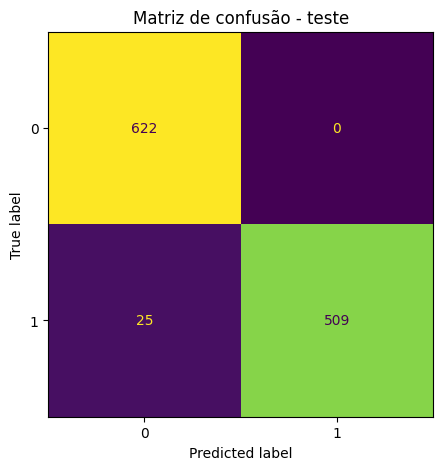

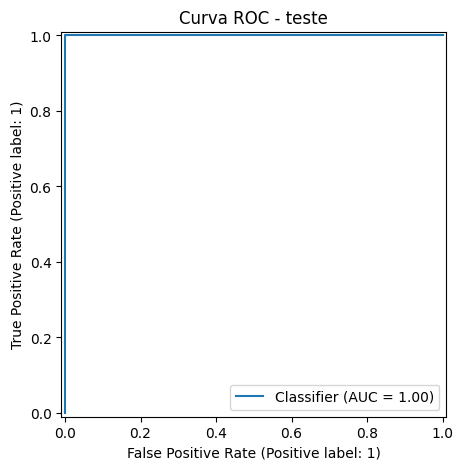

In [49]:
# Visualizações de avaliação
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=ax, colorbar=False)
ax.set_title("Matriz de confusão - teste")
plt.show()

fig, ax = plt.subplots(figsize=(6, 5))
RocCurveDisplay.from_predictions(y_test, y_prob, ax=ax)
ax.set_title("Curva ROC - teste")
plt.show()


### Importância das variáveis

Para reduzir viés de interpretação de `feature_importances_` do Random Forest, usamos **permutation importance** no conjunto de teste.


In [50]:
perm = permutation_importance(
    best_model,
    X_test,
    y_test,
    n_repeats=20,
    random_state=42,
    scoring="roc_auc",
)

importance_df = (
    pd.DataFrame({
        "feature": X_test.columns,
        "importance_mean": perm.importances_mean,
        "importance_std": perm.importances_std,
    })
    .sort_values("importance_mean", ascending=False)
    .reset_index(drop=True)
)

importance_df


,feature,importance_mean,importance_std
0,ian,4.071788e-01,1.925435e-02
1,ipp,4.851753e-04,3.204221e-04
2,ips,3.978648e-04,3.651259e-04
3,ieg,7.526765e-07,1.614311e-06
4,desempenho_academico,2.220446e-17,4.440892e-17
5,iaa,2.220446e-17,4.440892e-17
6,inde,2.220446e-17,4.440892e-17
7,variacao_indicadores,1.665335e-17,3.964289e-17
8,media_indicadores,1.665335e-17,3.964289e-17
9,ida,1.110223e-17,3.330669e-17


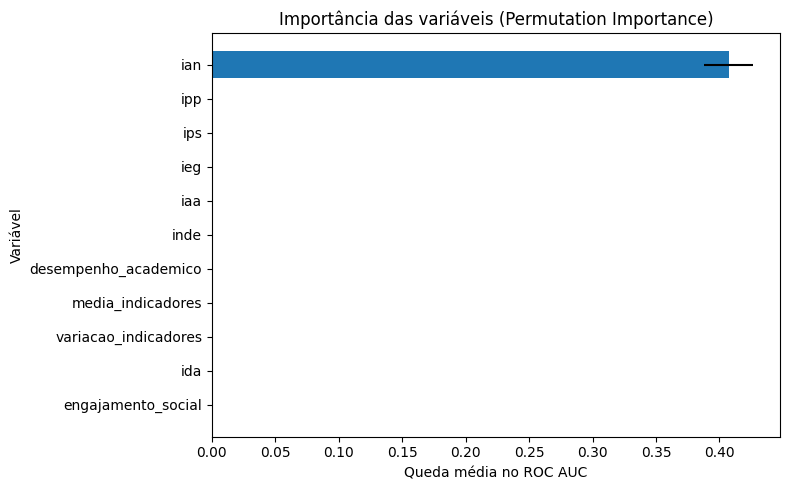

In [51]:
fig, ax = plt.subplots(figsize=(8, 5))
plot_df = importance_df.sort_values("importance_mean", ascending=True)
ax.barh(plot_df["feature"], plot_df["importance_mean"], xerr=plot_df["importance_std"])
ax.set_title("Importância das variáveis (Permutation Importance)")
ax.set_xlabel("Queda média no ROC AUC")
ax.set_ylabel("Variável")
plt.tight_layout()
plt.show()


In [52]:
# Persistência para o Streamlit
MODELS_DIR = PROJECT_ROOT / "models"
MODELS_DIR.mkdir(parents=True, exist_ok=True)

joblib.dump(best_model, MODELS_DIR / "modelo_risco_defasagem.joblib")

with open(MODELS_DIR / "metricas_modelo.json", "w", encoding="utf-8") as f:
    json.dump(metricas, f, ensure_ascii=False, indent=4)

importance_df.to_csv(MODELS_DIR / "importancia_variaveis.csv", index=False, encoding="utf-8")

print("Arquivos salvos em:", MODELS_DIR)
print("- modelo_risco_defasagem.joblib")
print("- metricas_modelo.json")
print("- importancia_variaveis.csv")


Arquivos salvos em: C:\Users\Diego Maradini\Documents\TechChallenger5\FIAP-TECH-CHALLENGER-5\models
- modelo_risco_defasagem.joblib
- metricas_modelo.json
- importancia_variaveis.csv


## Conclusão

Esta versão do notebook melhora a robustez metodológica do projeto por quatro motivos principais:

1. avalia o modelo em **cenário temporal realista**;
2. compara um **baseline linear** com um modelo de árvore;
3. usa **validação cruzada** e **tuning** para reduzir arbitrariedade;
4. entrega artefatos prontos para o **Streamlit**.


In [53]:
from sklearn.metrics import roc_auc_score

train_pred = best_model.predict_proba(X_train)[:,1]
test_pred  = best_model.predict_proba(X_test)[:,1]

print("ROC treino:", roc_auc_score(y_train, train_pred))
print("ROC teste :", roc_auc_score(y_test, test_pred))

ROC treino: 0.9999780745028395
ROC teste : 1.0
